<a id="inicio"></a>
    # AED 02 · Elegir descripción, regresión, segmentación y tendencias

    **Núcleo U1 · S03–S04 · RA1 / CE1.3–1.4** · Colección docente · Edición 2026-10-08.

    Ejecute todas las celdas en orden con el entorno documentado en `../reproducibilidad/README.md`.
    Los controles necesitan kernel activo; las salidas guardadas permiten lectura. Los datos son
    casos docentes locales; las simulaciones y parámetros económicos se identifican como supuestos.
    Consulte la [guía maestra](../guia_maestra_aed.html), el
    [manual científico](../material_propio/AED_manual_cientifico.pdf) y la
    [matriz curricular](../COBERTURA.md). Los ejercicios son formativos.

### Antes de ejecutar

Núcleo · 90–120 min orientativos.

**Objetivo:** Elegir técnica según pregunta, respuesta, estructura y decisión.

**Preparación:** Módulo 01, lectura de regresión, clasificación y segmentación.

**Ejemplo de referencia:** Distinguir describir demora, predecir incumplimiento y asignar turnos con capacidad limitada.

**Práctica:** Comparar predicción y agrupamiento sobre el mismo caso y discutir cómo se usaría cada salida.

**Criterio de logro:** Justificar técnica, referencia, validación y una implicación práctica que no confunda asociación y efecto.

[Guía y secuencia](../guia_maestra_aed.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/AED_manual_cientifico.html#sec-tecnicas)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
RAIZ=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'_transversal/datos').is_dir())
sys.path.insert(0,str(RAIZ/'04_Analitica_Estrategica_Datos/reproducibilidad'))
from aed_recursos import (casapeumo, indicadores, boldonet, plan_produccion,
                         decision, solar, resumen_solar, pregunta, DATOS, SEMILLA)
plt.rcParams.update({'figure.figsize':(8,3.5),'axes.spines.top':False,'axes.spines.right':False})

<a id="descripcion"></a>
## 1. La técnica sigue a la pregunta

Describir concentración de margen requiere distribución y agregación; anticipar una cantidad
requiere regresión evaluada fuera de muestra; estimar un evento requiere clasificación; explorar
perfiles requiere segmentación. Una tendencia temporal no demuestra causalidad y una regresión
de variables que forman una identidad contable no descubre un mecanismo nuevo.

En CasaPeumo el ingreso se calcula a partir de unidades, precio y descuento. Ajustar ingreso con
esas mismas variables sería reconstruir una fórmula. Primero describiremos ticket, dispersión,
concentración y cambios mensuales; después usaremos simulaciones explícitas para evaluar modelos.

In [2]:
ventas,_,_=casapeumo()
display(ventas[['Ingreso','Margen','TiempoEntregaDias']].describe(percentiles=[.1,.5,.9]))
resumen=ventas.groupby('Canal').agg(n=('IdVenta','size'),ingreso=('Ingreso','sum'),margen=('Margen','sum'))
resumen['margen_pct']=resumen.margen/resumen.ingreso
display(resumen)
@widgets.interact(canal=['Todos',*sorted(ventas.Canal.unique())])
def describir(canal='Todos'):
    f=ventas if canal=='Todos' else ventas.loc[ventas.Canal.eq(canal)]
    fig,ax=plt.subplots(); ax.hist(f.Ingreso,bins=18,color='#176b78');ax.set(xlabel='Ingreso por venta (UM del caso)',ylabel='Frecuencia',title=f'Distribución: {canal}');plt.show();plt.close(fig)

,Ingreso,Margen,TiempoEntregaDias
count,675.000000,675.000000,675.000000
mean,150.378683,44.950224,0.920000
std,136.415534,48.021056,1.212986
min,33.684000,5.663200,0.000000
10%,42.000000,11.201500,0.000000
50%,105.973500,29.550000,0.000000
90%,304.443440,93.434940,3.000000
max,987.000000,380.130000,7.000000


,n,ingreso,margen,margen_pct
Canal,,,,
Marketplace,138,23555.9741,7249.6341,0.307762
Sitio web,275,40978.4763,12242.1163,0.298745
Tienda física,262,36971.1607,10849.6507,0.293463


interactive(children=(Dropdown(description='canal', options=('Todos', 'Marketplace', 'Sitio web', 'Tienda físi…

<a id="regresion"></a>
## 2. Regresión y tendencia con orden temporal

Modelo $y_t=\beta_0+\beta_1 t+\beta_2 x_t+\epsilon_t$: la variable exógena $x_t$ solo puede usarse
si está disponible al decidir. En el ejemplo simulado, inversión planificada se conoce antes de
la venta. Separamos 96 semanas iniciales y 24 finales; comparamos MAE con un pronóstico ingenuo.
No ajustamos hiperparámetros mirando el test. La hipótesis de ruido independiente es una
simplificación; inspeccione residuos y use validación con origen móvil si hay estacionalidad.

,modelo,MAE
0,Regresión,6.078789
1,Último valor,13.637962


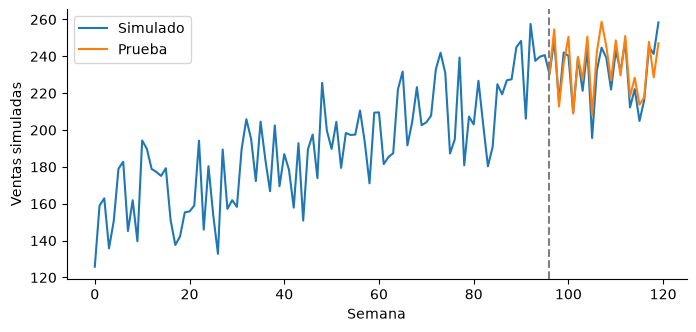

In [3]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, roc_auc_score, brier_score_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
rng=np.random.default_rng(SEMILLA)
t=np.arange(120); inversion=rng.uniform(10,40,120)
y=100+0.8*t+2*inversion+rng.normal(0,8,120)
X=np.column_stack([t,inversion]); corte=96
reg=LinearRegression().fit(X[:corte],y[:corte])
pred=reg.predict(X[corte:]); ingenuo=np.repeat(y[corte-1],len(pred))
display(pd.DataFrame({'modelo':['Regresión','Último valor'],'MAE':[mean_absolute_error(y[corte:],pred),mean_absolute_error(y[corte:],ingenuo)]}))
fig,ax=plt.subplots();ax.plot(t,y,label='Simulado');ax.plot(t[corte:],pred,label='Prueba');ax.axvline(corte,color='grey',linestyle='--');ax.legend();ax.set(xlabel='Semana',ylabel='Ventas simuladas');plt.show();plt.close(fig)
assert mean_absolute_error(y[corte:],pred)<mean_absolute_error(y[corte:],ingenuo)

<a id="logistica"></a>
## 3. Probabilidad de evento y decisión

La logística especifica $P(Y=1\mid x)=1/(1+e^{-(\beta_0+x^T\beta)})$.
Se escala usando entrenamiento. AUC evalúa ordenamiento y Brier el error cuadrático de
probabilidades; ninguna métrica prueba calibración en otra población. El costo/beneficio de una
acción exige además su efecto: alto riesgo no equivale a alta respuesta al tratamiento.

In [4]:
from sklearn.model_selection import train_test_split
Xc=rng.normal(size=(800,3)); p=1/(1+np.exp(-(-.7+1.1*Xc[:,0]-.6*Xc[:,1])))
yc=rng.binomial(1,p)
Xa,Xb,ya,yb=train_test_split(Xc,yc,test_size=.25,stratify=yc,random_state=SEMILLA)
clas=make_pipeline(StandardScaler(),LogisticRegression()).fit(Xa,ya)
pb=clas.predict_proba(Xb)[:,1]
display(pd.Series({'AUC_prueba':roc_auc_score(yb,pb),'Brier_prueba':brier_score_loss(yb,pb)}))
assert np.all((pb>=0)&(pb<=1))

AUC_prueba      0.769627
Brier_prueba    0.180217
dtype: float64

<a id="segmentacion"></a>
## 4. Segmentos exploratorios y estabilidad

Agrupamos clientes con frecuencia, ingreso y tiempo de entrega. Estandarizar evita que la escala
monetaria domine la distancia. K-means minimiza distancias cuadráticas y favorece grupos compactos;
no garantiza segmentos comercialmente útiles. El número de grupos es una decisión exploratoria:
silhouette no reemplaza tamaños, estabilidad, interpretabilidad ni validación del uso posterior.
No use etiquetas de cluster como jerarquía de valor humano. Un cliente sin ventas observadas no
queda representado en este agregado.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
perfil=ventas.groupby('IdCliente').agg(frecuencia=('IdVenta','size'),ingreso=('Ingreso','sum'),demora=('TiempoEntregaDias','mean'))
Z=StandardScaler().fit_transform(perfil)
@widgets.interact(k=widgets.IntSlider(value=3,min=2,max=6,step=1,description='Grupos'))
def segmentar(k=3):
    grupos=KMeans(n_clusters=k,n_init=10,random_state=SEMILLA).fit_predict(Z)
    display(perfil.assign(grupo=grupos).groupby('grupo').agg(n=('ingreso','size'),ingreso=('ingreso','mean'),frecuencia=('frecuencia','mean')))
    print('Silhouette:',round(silhouette_score(Z,grupos),3))
    assert len(np.unique(grupos))==k

interactive(children=(IntSlider(value=3, description='Grupos', max=6, min=2), Output()), _dom_classes=('widget…

<a id="tendencias"></a>
## 5. Pocos períodos no sostienen un pronóstico complejo

CasaPeumo tiene seis meses: grafique variación mensual sin inferir una estacionalidad anual.
Distinga crecimiento absoluto y relativo, períodos completos y denominador. Explore si el cambio
se debe a número de ventas, ticket o mezcla de canales. Esta descomposición orienta hipótesis;
no identifica el efecto de una campaña.

**Ejercicio resuelto.** ¿Usaría un modelo logístico para predecir ventas monetarias? No: para un
importe use regresión con pérdida adecuada; para probabilidad de compra defina evento y ventana.
¿Puede atribuir crecimiento a marketing? Se necesita un contrafactual y descartar cambios de
precio, mezcla, selección y calendario. Una asociación es un punto de partida para un piloto.

In [6]:
mensual=ventas.groupby('Mes').agg(ingreso=('Ingreso','sum'),n=('IdVenta','size'))
mensual['ticket']=mensual.ingreso/mensual.n
mensual['variacion']=mensual.ingreso.pct_change()
display(mensual)
assert np.allclose(mensual.ingreso,mensual.n*mensual.ticket)

,ingreso,n,ticket,variacion
Mes,,,,
2026-01,13512.2859,110,122.838963,NaN
2026-02,16921.6741,104,162.708405,0.252318
2026-03,18248.0194,112,162.928745,0.078381
2026-04,15324.9190,108,141.897398,-0.160187
2026-05,18513.5043,120,154.279202,0.208065
2026-06,18985.2084,121,156.902549,0.025479


<a id="autoevaluacion"></a>
## Autoevaluación
Seleccione y compruebe su respuesta.

In [7]:
auto_02=pregunta('¿Por qué estandarizar antes de K-means con ingresos y frecuencia?', ['Para demostrar causalidad', 'Para evitar que las unidades dominen la distancia', 'Para garantizar segmentos óptimos de negocio'], 1, 'La escala modifica las distancias; el valor del segmento se valida aparte con criterios de negocio.')